In [1]:
### pip install pystan
### conda install -c conda-forge fbprophet
!pip install prophet
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('/content/airline_passengers.csv')

In [3]:
df.head()

,,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.tail()

,,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


<Axes: >

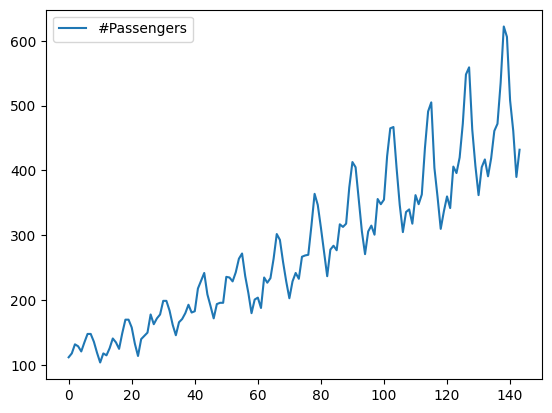

In [5]:
df.plot()

In [6]:
df.columns = ['ds','y']
df.head()

,ds,y
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [7]:
df.drop(143,axis=0,inplace=True)

In [8]:
df.tail()

,ds,y
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [9]:
df['ds'] = pd.to_datetime(df['ds'])

In [10]:
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [11]:
df.tail()

,ds,y
138,1960-07-01,622
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [12]:
dir(Prophet)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 

In [13]:
# Initialize the Model
model=Prophet()

In [14]:
df.columns

Index(['ds', 'y'], dtype='object')

In [15]:
df.dropna(axis=0,inplace=True)
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [16]:
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [17]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [18]:
df.tail()

,ds,y
138,1960-07-01,622
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [19]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)

In [20]:
future_dates.tail()

,ds
503,1961-10-28
504,1961-10-29
505,1961-10-30
506,1961-10-31
507,1961-11-01


In [21]:
prediction=model.predict(future_dates)

In [22]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,107.626899,55.389604,112.983651,107.626899,107.626899,-22.291151,-22.291151,-22.291151,-22.291151,-22.291151,-22.291151,0.0,0.0,0.0,85.335748
1,1949-02-01,109.773571,49.240190,106.680494,109.773571,109.773571,-30.908003,-30.908003,-30.908003,-30.908003,-30.908003,-30.908003,0.0,0.0,0.0,78.865568
2,1949-03-01,111.712500,82.394043,138.689543,111.712500,111.712500,-0.826593,-0.826593,-0.826593,-0.826593,-0.826593,-0.826593,0.0,0.0,0.0,110.885907
3,1949-04-01,113.859171,78.381468,136.963140,113.859171,113.859171,-5.335089,-5.335089,-5.335089,-5.335089,-5.335089,-5.335089,0.0,0.0,0.0,108.524082
4,1949-05-01,115.936595,84.327044,140.848615,115.936595,115.936595,-3.980715,-3.980715,-3.980715,-3.980715,-3.980715,-3.980715,0.0,0.0,0.0,111.955881


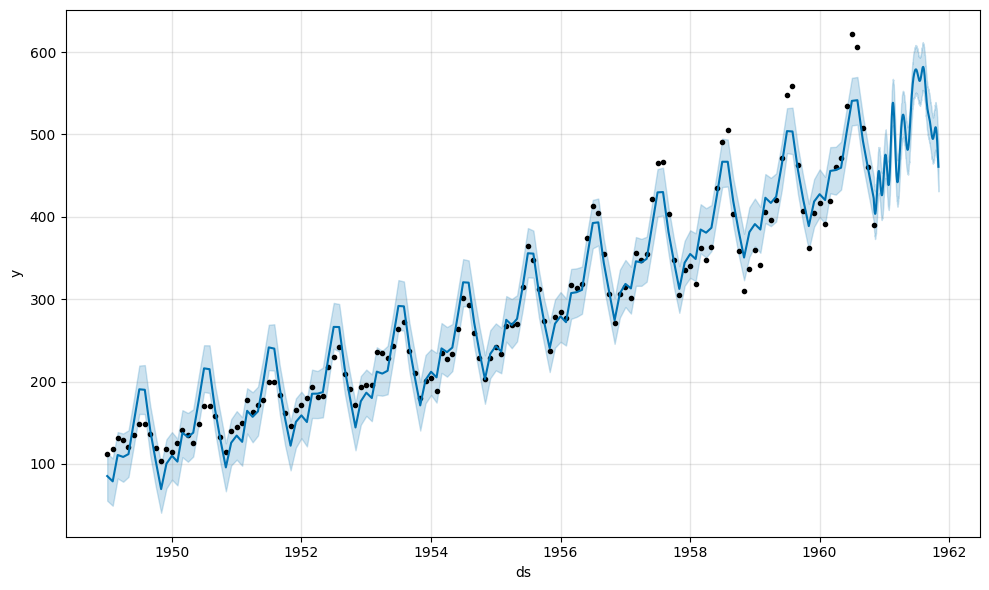

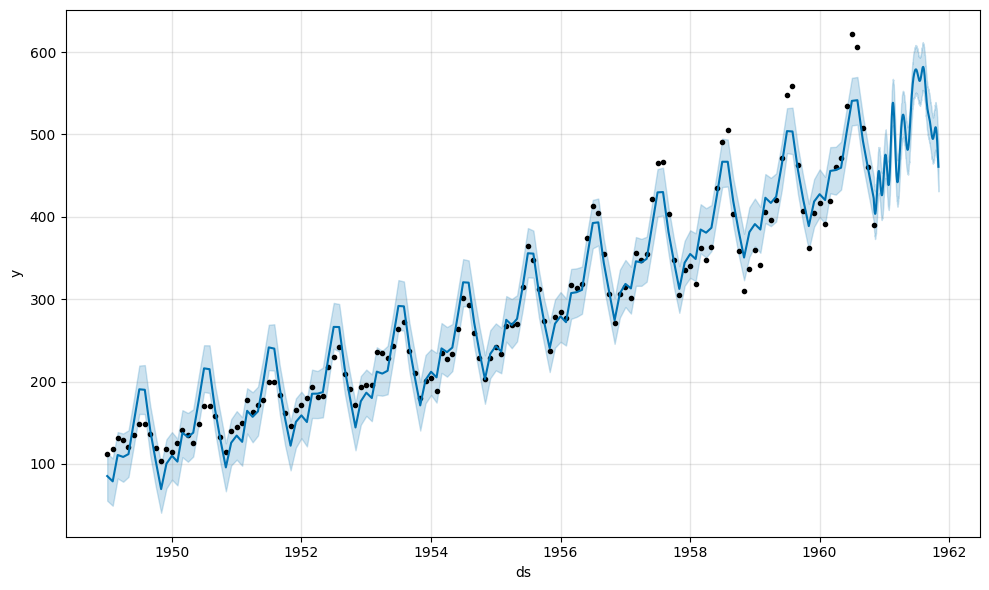

In [23]:
### plot the predicted projection
model.plot(prediction)

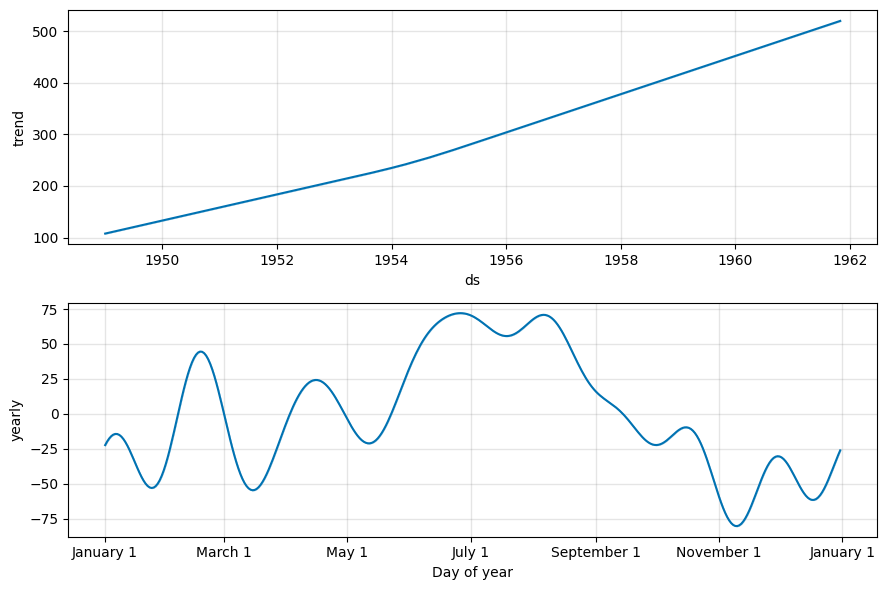

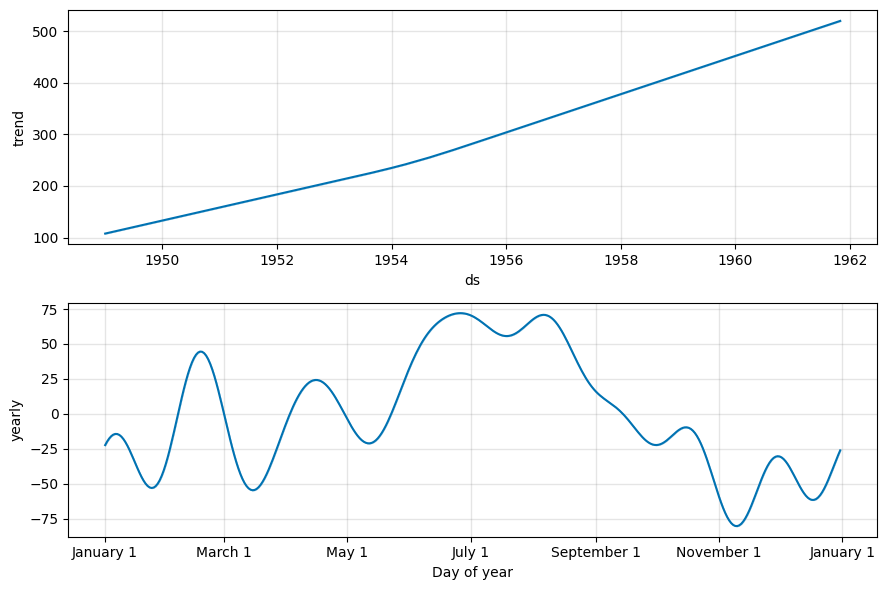

In [24]:
#### Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [25]:
#Time Series Analysis

1960-1962
#Cross Validation
1960-61 #Train dataset
1961-62 #Test dataset
1962-63 #Validation

1899

In [26]:
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [27]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
df_cv.head()

INFO:prophet:Making 18 forecasts with cutoffs between 1951-06-17 00:00:00 and 1959-11-02 00:00:00


  0%|          | 0/18 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 23.


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-07-01,211.625264,209.303534,214.290754,199,1951-06-17
1,1951-08-01,213.709504,211.203433,216.244286,199,1951-06-17
2,1951-09-01,204.451666,202.069420,207.249383,184,1951-06-17
3,1951-10-01,174.698742,171.936792,177.565415,162,1951-06-17
4,1951-11-01,154.867514,151.766767,157.867360,146,1951-06-17


In [28]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,39 days,735.446963,27.119125,21.329386,0.066842,0.056701,0.067785,0.285714
1,41 days,933.719451,30.556823,24.131505,0.073075,0.063444,0.074669,0.238095
2,45 days,895.105764,29.918318,23.993711,0.073910,0.070605,0.074859,0.190476
3,46 days,983.568376,31.361894,24.913956,0.074932,0.070605,0.076007,0.190476
4,49 days,968.726835,31.124377,24.155686,0.072056,0.070605,0.073236,0.238095


https://docs.google.com/document/d/1kflJtIrV23DaGH2bF7fLJyTYq-uqsu2D7SFrRpdQ3bk/edit?usp=sharing

In [29]:
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,39 days,735.446963,27.119125,21.329386,0.066842,0.056701,0.067785,0.285714
1,41 days,933.719451,30.556823,24.131505,0.073075,0.063444,0.074669,0.238095
2,45 days,895.105764,29.918318,23.993711,0.073910,0.070605,0.074859,0.190476
3,46 days,983.568376,31.361894,24.913956,0.074932,0.070605,0.076007,0.190476
4,49 days,968.726835,31.124377,24.155686,0.072056,0.070605,0.073236,0.238095


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


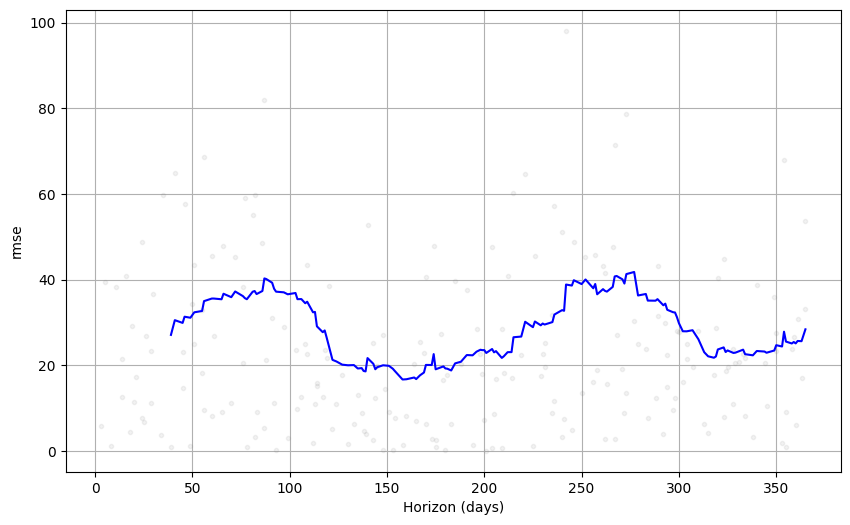

In [30]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

FINAL OUTCOME OF THE NOTEBOOK

This notebook successfully:

✅ Loads airline passenger time series data

✅ Cleans and prepares dataset

✅ Trains Prophet forecasting model

✅ Predicts future passenger counts for 365 days

✅ Visualizes trend and seasonality

✅ Evaluates model accuracy using cross-validation and RMSE